In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/game_data_by_genre.csv')
display(df.head())

,Genre,Game Name,Earnings,Players,Tournaments
0,Strategy,Age of Empires,965673.48,792,424
1,Strategy,Age of Empires II,5047880.13,2643,2416
2,Strategy,Age of Empires III,146206.97,196,206
3,Strategy,Age of Empires IV,1616476.52,945,684
4,Strategy,Age of Empires Online,12812.98,54,76


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Genre        690 non-null    object 
 1   Game Name    690 non-null    object 
 2   Earnings     690 non-null    float64
 3   Players      690 non-null    int64  
 4   Tournaments  690 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 27.1+ KB


In [ ]:
df_sorted_earnings = df.sort_values(by='Earnings', ascending=False).reset_index(drop=True)
display(df_sorted_earnings.head(10))

,Genre,Game Name,Earnings,Players,Tournaments
0,Multiplayer Online Battle Arena,Dota 2,3.822783e+08,5069,1987
1,Battle Royale,Fortnite,2.091090e+08,11509,2674
2,First-Person Shooter,Counter-Strike: Global Offensive,1.627696e+08,16582,7108
3,Multiplayer Online Battle Arena,League of Legends,1.220131e+08,9687,3035
4,Multiplayer Online Battle Arena,Arena of Valor,1.115113e+08,2291,183
5,Battle Royale,PLAYERUNKNOWN'S BATTLEGROUNDS Mobile,8.978512e+07,4312,344
6,Battle Royale,PLAYERUNKNOWN’S BATTLEGROUNDS,6.703771e+07,4017,642
7,Sports,Rocket League,5.814657e+07,10476,5373
8,First-Person Shooter,Counter-Strike 2,5.518732e+07,4887,907
9,First-Person Shooter,Rainbow Six Siege,4.988525e+07,3084,573


/tmp/ipykernel_29537/4280004365.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data['Earnings'], palette='viridis')


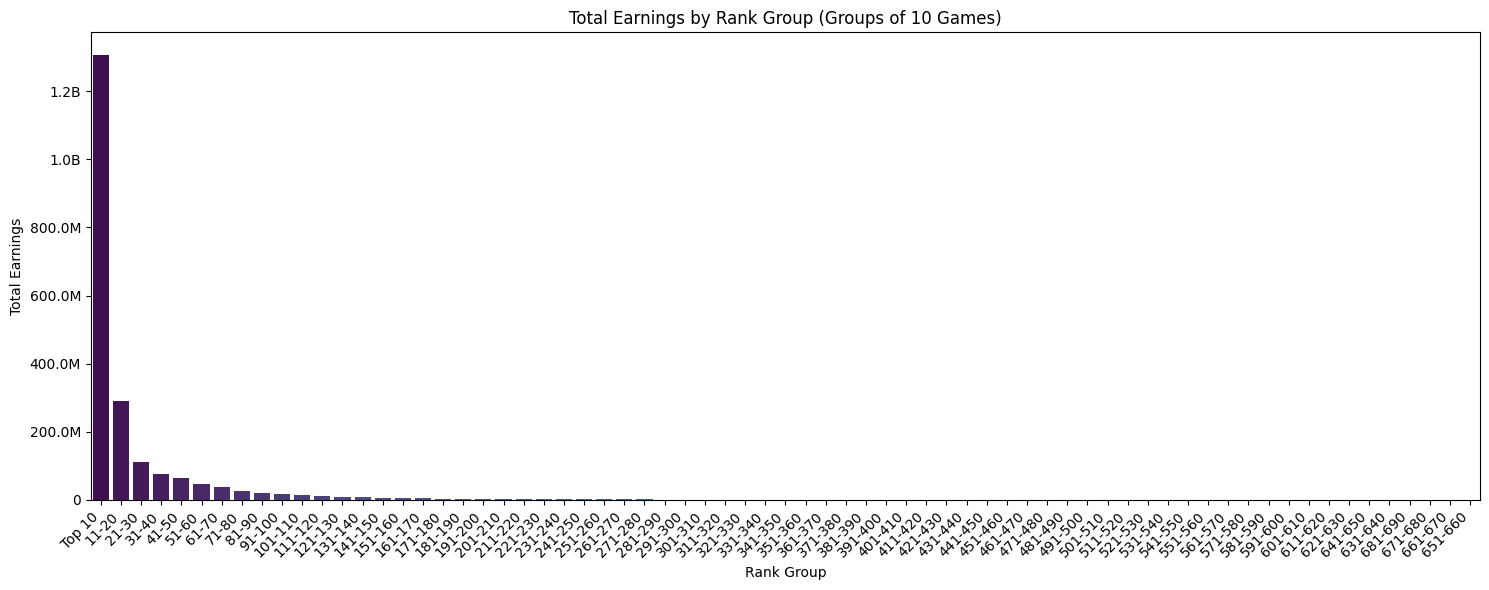

In [ ]:
rank_groups = [f"{i}-{i+9}" for i in range(1, 691, 10)]
rank_groups[0] = 'Top 10'
df_sorted_earnings['Rank Group'] = [rank_groups[i // 10] for i in df_sorted_earnings.index]
data = df_sorted_earnings.groupby('Rank Group').agg({'Earnings': 'sum'}).sort_values(by='Earnings', ascending=False)

def human_readable_format(num, pos):
    if num >= 1e9:
        return f'{num*1e-9:.1f}B'
    elif num >= 1e6:
        return f'{num*1e-6:.1f}M'
    else:
        return f'{num:.0f}'

plt.figure(figsize=(15, 6))
sns.barplot(x=data.index, y=data['Earnings'], palette='viridis')
plt.xlabel('Rank Group')
plt.ylabel('Total Earnings')
plt.title('Total Earnings by Rank Group (Groups of 10 Games)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(human_readable_format))
plt.tight_layout()
plt.show()

/tmp/ipykernel_29537/2504002902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data['Earnings'], palette='viridis')


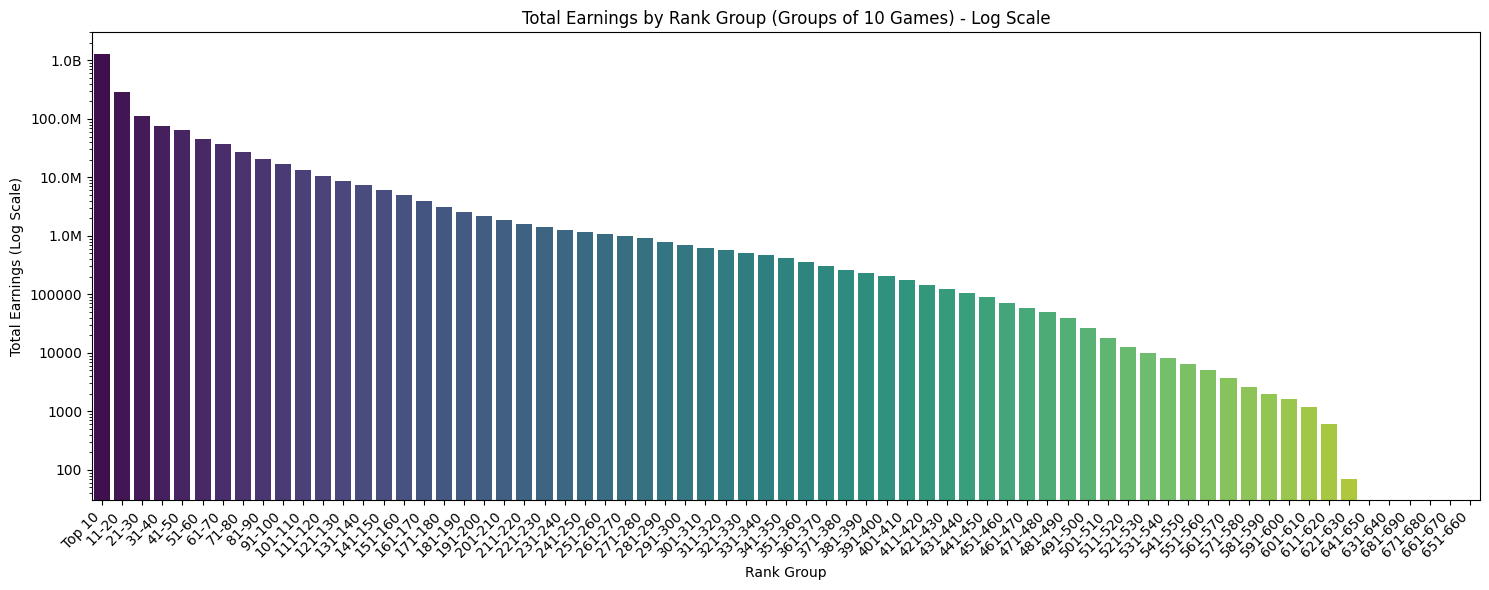

In [ ]:
plt.figure(figsize=(15, 6))
sns.barplot(x=data.index, y=data['Earnings'], palette='viridis')
plt.xlabel('Rank Group')
plt.ylabel('Total Earnings (Log Scale)')
plt.title('Total Earnings by Rank Group (Groups of 10 Games) - Log Scale')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(human_readable_format))
plt.tight_layout()
plt.show()

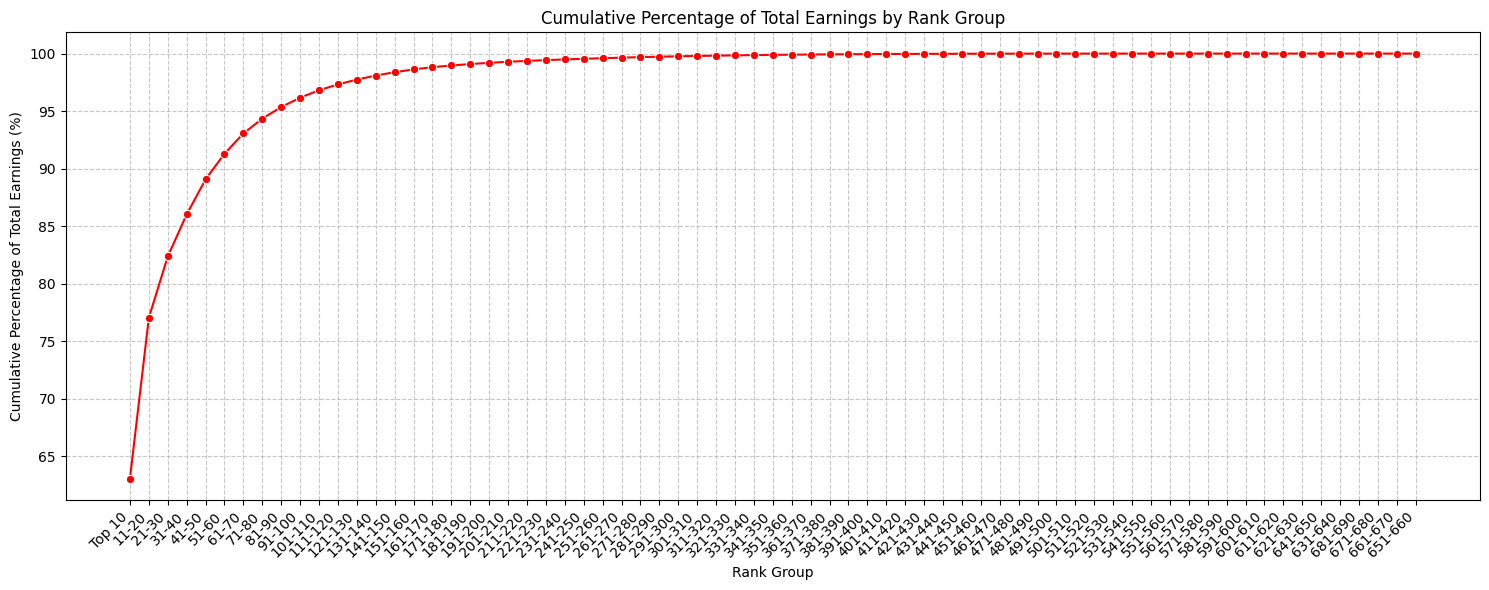

In [ ]:
data['Cumulative Earnings'] = data['Earnings'].cumsum()
data['Cumulative Percentage'] = (data['Cumulative Earnings'] / data['Earnings'].sum()) * 100

plt.figure(figsize=(15, 6))
sns.lineplot(x=data.index, y=data['Cumulative Percentage'], marker='o', color='red')
plt.xlabel('Rank Group')
plt.ylabel('Cumulative Percentage of Total Earnings (%)')
plt.title('Cumulative Percentage of Total Earnings by Rank Group')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_29537/1728078432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Earnings', y='Genre', data=total_genre_earnings, palette='viridis', ax=axes[0])
/tmp/ipykernel_29537/1728078432.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Earnings', y='Genre', data=genre_earnings, palette='viridis', ax=axes[1])


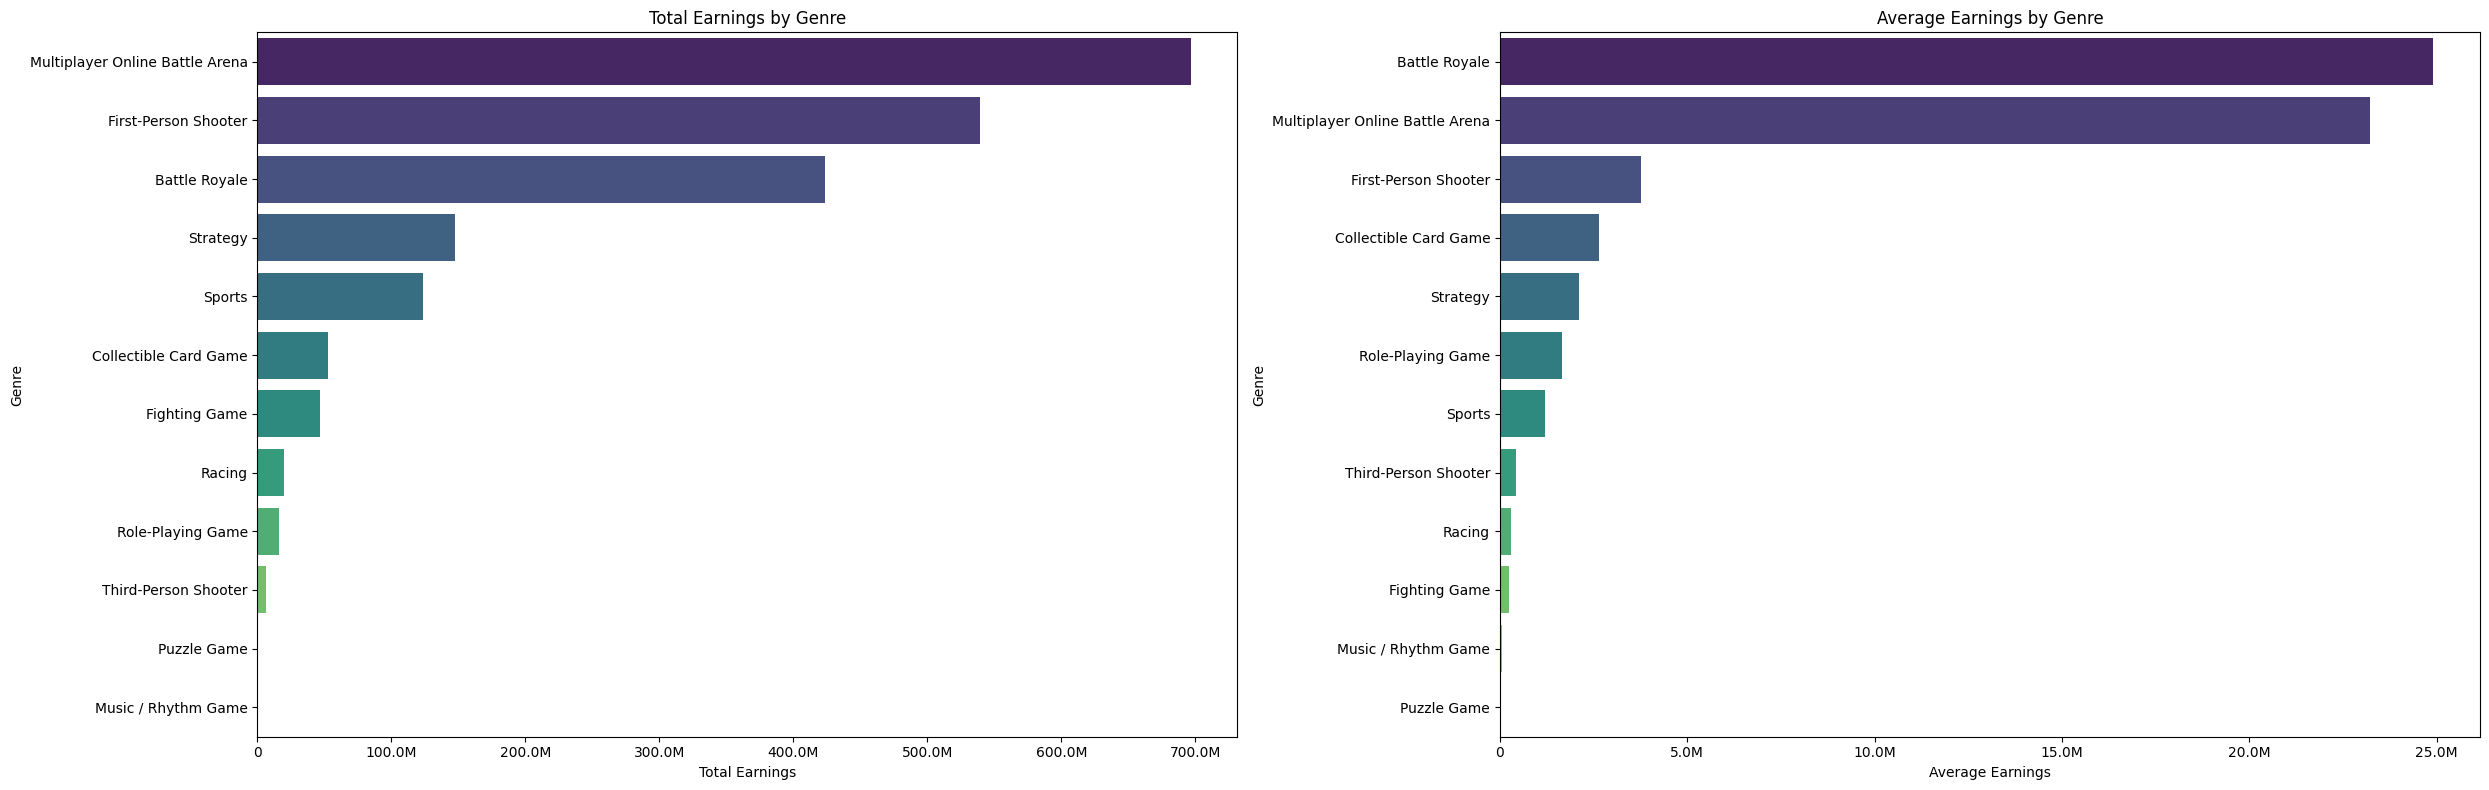

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(25, 8))

total_genre_earnings = df.groupby('Genre')['Earnings'].sum().sort_values(ascending=False).reset_index()

sns.barplot(x='Earnings', y='Genre', data=total_genre_earnings, palette='viridis', ax=axes[0])
axes[0].set_title('Total Earnings by Genre')
axes[0].set_xlabel('Total Earnings')
axes[0].set_ylabel('Genre')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(human_readable_format))

genre_earnings = df.groupby('Genre')['Earnings'].mean().sort_values(ascending=False).reset_index()

sns.barplot(x='Earnings', y='Genre', data=genre_earnings, palette='viridis', ax=axes[1])
axes[1].set_title('Average Earnings by Genre')
axes[1].set_xlabel('Average Earnings')
axes[1].set_ylabel('Genre')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(human_readable_format))

plt.tight_layout()
plt.show()

/tmp/ipykernel_29537/220673943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Number of Games', y='Genre', data=games_per_genre, palette='viridis')


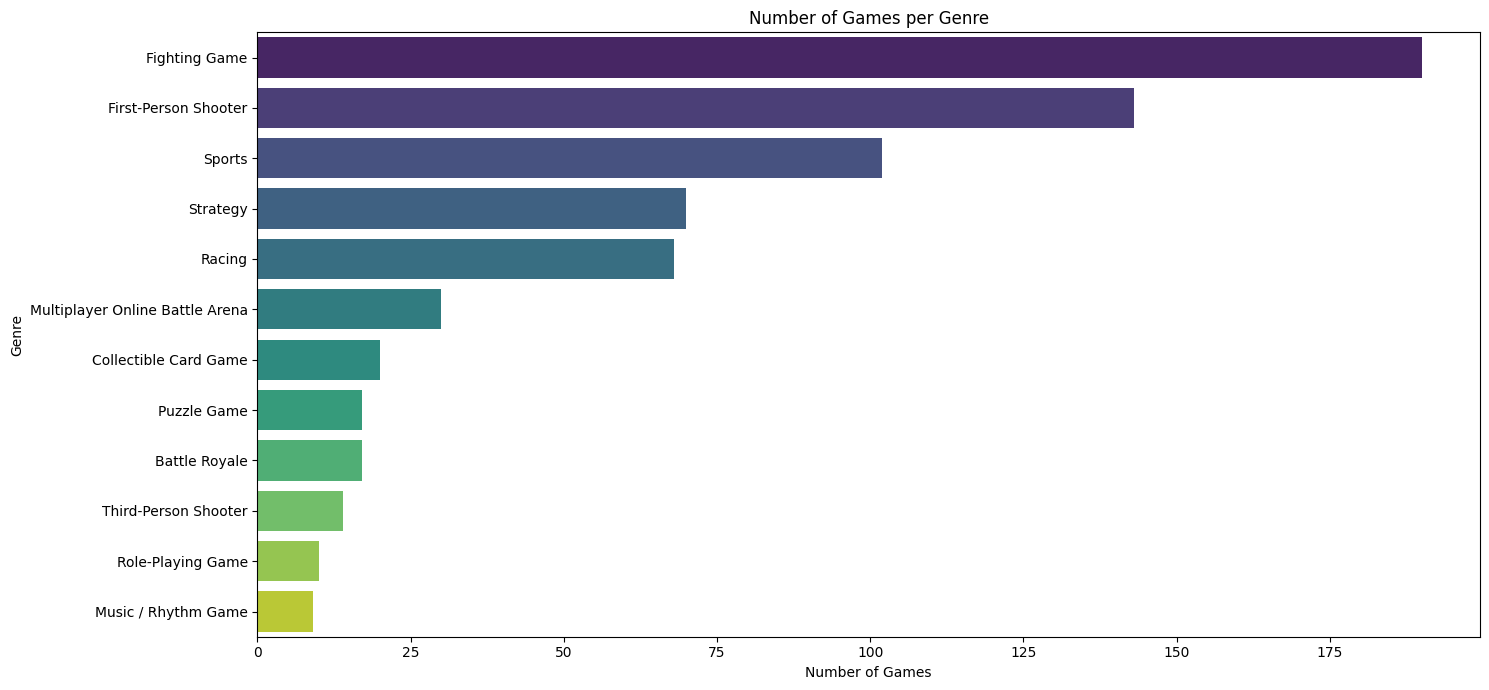

In [ ]:
games_per_genre = df['Genre'].value_counts().reset_index()
games_per_genre.columns = ['Genre', 'Number of Games']

plt.figure(figsize=(15, 7))
sns.barplot(x='Number of Games', y='Genre', data=games_per_genre, palette='viridis')
plt.title('Number of Games per Genre')
plt.xlabel('Number of Games')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [ ]:
correlation_matrix = df[['Players', 'Tournaments', 'Earnings']].corr()
display(correlation_matrix)

,Players,Tournaments,Earnings
Players,1.000000,0.785435,0.715009
Tournaments,0.785435,1.000000,0.529133
Earnings,0.715009,0.529133,1.000000


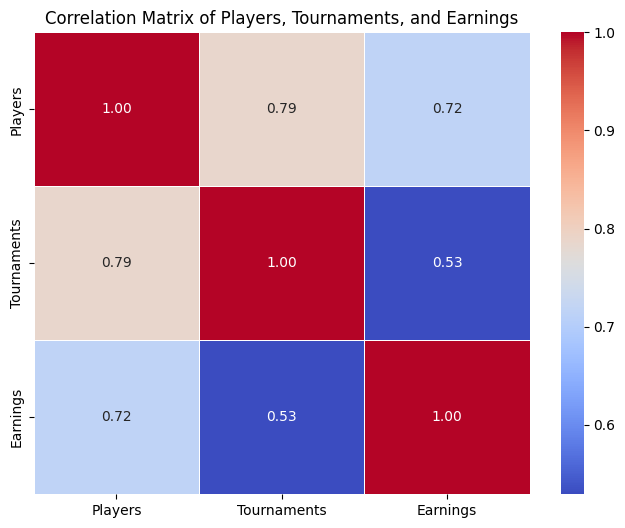

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Players, Tournaments, and Earnings')
plt.show()

**Observations & Potential Hypotheses**

1. **Players and Earnings ($r = 0.72$):** There is a strong positive correlation between a game's player base and its total earnings.
    * **Hypothesis A (Publisher Investment):** Larger player bases generate higher engagement and in-game revenue, leading publishers to allocate larger prize pools to sustain community interest.
    * **Hypothesis B (Player Attraction):** High prize pools attract higher volumes of competitive players seeking financial return.


2. **Players and Tournaments ($r = 0.79$):** There is a strong positive correlation between player count and total tracked tournaments.
    * **Hypothesis A (Grassroots Demand):** A larger player base creates demand for more local and community-run competitive events.
    * **Hypothesis B (Access & Participation):** Ecosystems with numerous entry-level tournaments lower the barrier to entry, resulting in a higher number of total active competitive players.


3. **Tournaments and Earnings ($r = 0.53$):** There is a moderate positive correlation between total tournaments and overall earnings.
    * **Hypothesis A (Prize Pool Concentration):** Total earnings are heavily concentrated in a small number of premier "Tier 1" mega-events rather than being evenly distributed across all tournaments.
    * **Hypothesis B (Open vs. Franchised Models):** High-frequency tournament ecosystems (e.g., fighting games) feature lower average prize pools per event compared to low-frequency, franchised leagues.
